# TPI 3ra entrega \- Ecobici 2024 \- Grupo 1

Integrantes:
Hurtado González, Federico Nicolás\.
Arnaudin, Franco\.

Repositorios:
https://github\.com/fedenh3/DSIA
https://github.com/FrancoArnaudinIFTS24/DSIA_Arnaudin_Franco

## 1 \- Carga y preparación\.

Carga de librerías y preparación de los datos\.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga del dataset

df_bicis = pd.read_csv("badata_ecobici_recorridos_realizados_2024.csv")

In [3]:
# Muestra del 1% para trabajar más rápido, ya que el dataset completo tiene más de 3.5 millones de filas
df = df_bicis.sample(frac=0.01, random_state=42)
df = df.reset_index(drop=True)

print(f"Muestra: {len(df)} filas")
print(f"Dataset original: {len(df_bicis)} filas")
df.head()

Muestra: 35593 filas
Dataset original: 3559284 filas


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,23965041,587,2024-11-21 00:43:00,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-11-21 00:52:47,213,136 - Acevedo,Acevedo y Padilla,-58.442685,-34.599659,756727.0,FIT,MALE
1,22961018,1234,2024-09-11 17:13:47,299,221 - CULPINA,Culpina 121,-58.466143,-34.631705,2024-09-11 17:34:21,407,330 - Parque Avellaneda,Remedios 3895,-58.478266,-34.642425,1204680.0,FIT,MALE
2,21800302,0,2024-05-22 15:57:48,525,317 - ESCUELA RAGGIO,Av. Libertador 8620 (y Pico),-58.466813,-34.536691,2024-05-22 15:57:48,464,377 - CIUDAD UNIVERSITARIA III,Intendente Guiraldes 2160 - Pabellón III,-58.444100,-34.541000,849987.0,FIT,MALE
3,20749173,647,2024-02-21 21:01:03,489,288 - SECRETARÍA DE DEPORTES,AV LIBERTADOR 7100,-58.456566,-34.547604,2024-02-21 21:11:50,289,255 - BARRANCAS DE BELGRANO,"Sucre, Antonio Jose De, Mcal. Y Vertiz Virrey Av.",-58.448314,-34.559801,249614.0,FIT,MALE
4,23288851,1304,2024-10-03 20:12:13,327,366 - VILLA OLÍMPICA,Escalada 4347,-58.454286,-34.677131,2024-10-03 20:33:57,327,366 - VILLA OLÍMPICA,Escalada 4347,-58.454286,-34.677131,827124.0,FIT,MALE


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35593 entries, 0 to 35592
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_recorrido                35593 non-null  int64  
 1   duracion_recorrido          35593 non-null  int64  
 2   fecha_origen_recorrido      35593 non-null  object 
 3   id_estacion_origen          35593 non-null  int64  
 4   nombre_estacion_origen      35593 non-null  object 
 5   direccion_estacion_origen   35593 non-null  object 
 6   long_estacion_origen        35593 non-null  float64
 7   lat_estacion_origen         35593 non-null  float64
 8   fecha_destino_recorrido     35558 non-null  object 
 9   id_estacion_destino         35593 non-null  int64  
 10  nombre_estacion_destino     35593 non-null  object 
 11  direccion_estacion_destino  35593 non-null  object 
 12  long_estacion_destino       35593 non-null  float64
 13  lat_estacion_destino        355

In [5]:
# Forma del dataset

df.shape

(35593, 17)

## 2\. Limpieza del dataset

Realizamos las siguientes transformaciones:
\- Conversión de columnas de fechas de "object" a "datetime"\.
\- Eliminamos filas con valores nulos en columnas clave\.
\- Filtramos registros que la duración sea menor o igual a 0 \(datos inválidos\)\.
\- Creamos variables derivadas: hora de inicio, día de la semana, mes, distancia recorrida, velocidad promedio del trayecto, etcétera

In [6]:
# Conversión de fechas
df['fecha_origen_recorrido'] = pd.to_datetime(df['fecha_origen_recorrido'], errors='coerce')
df['fecha_destino_recorrido'] = pd.to_datetime(df['fecha_destino_recorrido'], errors='coerce')

In [7]:
# vemos los nulos antes de limpiar

print("Nulos antes de limpiar: ")
print (df.isnull().sum())
print(f"\nTotal de filas antes: {len(df)}")

Nulos antes de limpiar: 
id_recorrido                    0
duracion_recorrido              0
fecha_origen_recorrido          0
id_estacion_origen              0
nombre_estacion_origen          0
direccion_estacion_origen       0
long_estacion_origen            0
lat_estacion_origen             0
fecha_destino_recorrido        35
id_estacion_destino             0
nombre_estacion_destino         0
direccion_estacion_destino      0
long_estacion_destino           0
lat_estacion_destino            0
id_usuario                      0
modelo_bicicleta                0
genero                        114
dtype: int64

Total de filas antes: 35593


In [8]:
# eliminamos nulos en las columnas clave

df = df.dropna(subset=['fecha_destino_recorrido', 'genero'])

In [9]:
# eliminamos registros con duración invalida

df = df[df['duracion_recorrido'] > 0]

In [10]:
#vemos los nulos después de limpiar

print(f"Total de filas después de limpiar: {len(df)}")
print("\nNulos después de limpiar: ")
print(df.isnull().sum())

Total de filas después de limpiar: 35139

Nulos después de limpiar: 
id_recorrido                  0
duracion_recorrido            0
fecha_origen_recorrido        0
id_estacion_origen            0
nombre_estacion_origen        0
direccion_estacion_origen     0
long_estacion_origen          0
lat_estacion_origen           0
fecha_destino_recorrido       0
id_estacion_destino           0
nombre_estacion_destino       0
direccion_estacion_destino    0
long_estacion_destino         0
lat_estacion_destino          0
id_usuario                    0
modelo_bicicleta              0
genero                        0
dtype: int64


In [11]:
# creamos variables temporales derivadas para el luego cálculo de las hipótesis

df['hora_inicio'] = df['fecha_origen_recorrido'].dt.hour
df['dia_semana'] = df['fecha_origen_recorrido'].dt.day_name()
df['mes'] = df['fecha_origen_recorrido'].dt.month
df['duracion_minutos'] = df['duracion_recorrido'] / 60
df['duracion_horas'] = df['duracion_recorrido']/ 3600
df['es_fin_de_semana'] = df['fecha_origen_recorrido'].dt.dayofweek >= 5
df['tipo_dia'] = np.where(df['es_fin_de_semana'], 'Fin de semana', 'Día hábil')

# Turnos horarios
def clasificar_hora(hora):
    if 7 <= hora <= 9:
        return 'Hora pico mañana'
    elif 17 <= hora <= 19:
        return 'Hora pico tarde'
    elif 10 <= hora <= 16:
        return 'Media jornada'
    else:
        return 'Noche/madrugada'

df['franja_horaria'] = df['hora_inicio'].apply(clasificar_hora)

# Viajes circulares: origen y destino en la misma estación
df['viaje_circular'] = df['id_estacion_origen'] == df['id_estacion_destino']

# Clasificación por duración
def clasificar_duracion(minutos):
    if minutos <= 10:
        return 'Corta'
    elif minutos <= 20:
        return 'Media'
    else:
        return 'Larga'

df['categoria_duracion'] = df['duracion_minutos'].apply(clasificar_duracion)

def clasificar_pico(hora):
    if (7 <= hora <= 9) or (17 <= hora <= 19):
        return 'Hora pico'
    else:
        return 'Fuera de pico'

df['periodo_horario'] = df['hora_inicio'].apply(clasificar_pico)

In [12]:
#vemos la vista previa

df [['fecha_origen_recorrido', 'hora_inicio', 'dia_semana', 'mes', 'duracion_minutos']].head(10)

,fecha_origen_recorrido,hora_inicio,dia_semana,mes,duracion_minutos
0,2024-11-21 00:43:00,0,Thursday,11,9.783333
1,2024-09-11 17:13:47,17,Wednesday,9,20.566667
3,2024-02-21 21:01:03,21,Wednesday,2,10.783333
4,2024-10-03 20:12:13,20,Thursday,10,21.733333
5,2024-10-29 23:21:39,23,Tuesday,10,27.950000
6,2024-02-02 17:09:24,17,Friday,2,0.033333
7,2024-07-12 16:12:26,16,Friday,7,14.216667
8,2024-02-20 07:53:37,7,Tuesday,2,0.583333
9,2024-06-19 09:21:43,9,Wednesday,6,43.300000
10,2024-05-30 16:28:04,16,Thursday,5,14.233333


In [13]:
# Calculamos la distancia recorrida en el viaje utilizando la fórmula de Haversine (distancia en geometrías esféricas)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 # Radio de la Tierra en km
    
    # Convertir grados a radianes
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Aplicar fórmula
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

# Crear la nueva columna pasando cada serie por separado
df['distancia_recorrida_km'] = haversine_distance(
    df['lat_estacion_origen'], 
    df['long_estacion_origen'],
    df['lat_estacion_destino'], 
    df['long_estacion_destino']
)

df['velocidad_km_h'] = df['distancia_recorrida_km']  / df['duracion_horas'] 

def clasificar_velocidad(v):
    if v < 5:
        return 'Baja'
    elif v <= 12:
        return 'Media'
    else:
        return 'Alta'

df['categoria_velocidad'] = df['velocidad_km_h'].apply(clasificar_velocidad)

### Filtro de velocidad y distancia para análisis de rendimiento (`df_vel`)

Para poder analizar la velocidad de los trayectos de manera realista, filtramos el dataset para crear `df_vel` bajo los siguientes criterios:
* **Velocidad > 0 y <= 30 km/h**: Las velocidades de 0 km/h corresponden a viajes circulares (origen y destino idénticos) donde la distancia calculada es 0 km, impidiendo registrar la velocidad real de pedaleo. Por otro lado, velocidades mayores a 30 km/h en bicicletas urbanas de paseo son físicamente inverosímiles y delatan fallas de geolocalización o de registro del GPS.
* **Distancia > 0 y Duración > 0**: Aseguran la consistencia física del cálculo.
* **Impacto en el dataset**: Este filtro conserva **29,915 filas** (84.05% de la muestra original), eliminando outliers de geolocalización y registros atípicos.

In [14]:
# Limpiamos las velocidades imposibles
df_vel = df[
    (df['velocidad_km_h'] > 0) &
    (df['velocidad_km_h'] <= 30) &
    (df['duracion_minutos'] > 0) &
    (df['distancia_recorrida_km'] > 0)
].copy()

## 3\. Análisis EDA \(estadísticas descriptivas\)

Exploramos las principales características del dataset limpio\.

In [15]:
# estadísticas descriptivas de la duración en minutos
df['duracion_minutos'].describe()

count    35139.000000
mean        21.064723
std        123.878779
min          0.016667
25%          8.425000
50%         14.866667
75%         24.566667
max      20520.566667
Name: duracion_minutos, dtype: float64

In [16]:
# distribución de variables categóricas

print("Modelos de bicicleta: ")
print(df['modelo_bicicleta'].value_counts())
print("\nGénero: ")
print(df['genero'].value_counts())

Modelos de bicicleta: 
modelo_bicicleta
FIT       25409
ICONIC     9730
Name: count, dtype: int64

Género: 
genero
MALE      21233
FEMALE    11254
OTHER      2652
Name: count, dtype: int64


## 4\. Análisis Univariado

Analizamos cada variable de interés de forma individual\.

### 4\.1\. Distribución de la duración de viajes \(filtro de 1 a 60 minutos\)

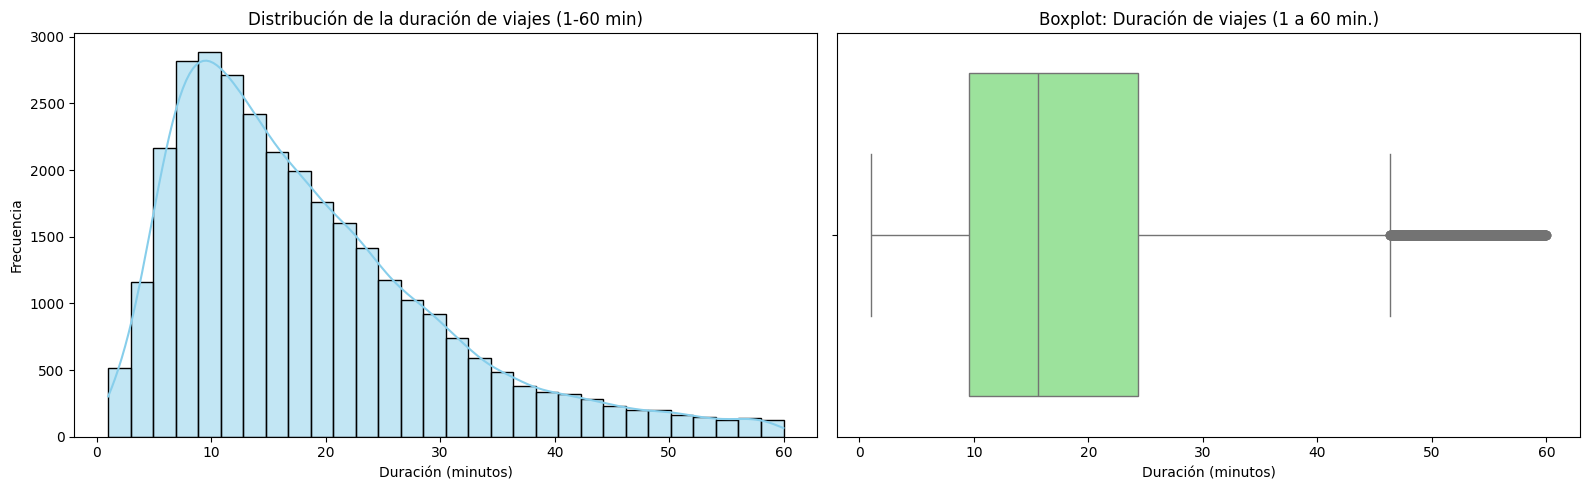

In [17]:
#filtro para visualización más limpia
df_filtrado = df[(df['duracion_minutos'] > 1) & (df['duracion_minutos'] < 60)]
fig, ax = plt.subplots(1, 2, figsize=(16,5))

# Histograma
sns.histplot(df_filtrado['duracion_minutos'], bins=30, kde=True, color='skyblue', ax=ax[0])
ax[0].set_title('Distribución de la duración de viajes (1-60 min)')
ax[0].set_xlabel('Duración (minutos)')
ax[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df_filtrado['duracion_minutos'], color='lightgreen', ax=ax[1])
ax[1].set_title('Boxplot: Duración de viajes (1 a 60 min.)')
ax[1].set_xlabel('Duración (minutos)')

plt.tight_layout()
plt.show()

### 4\.2\. Distribución de viajes por hora del día

/tmp/ipykernel_460/1496200185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hora_inicio', palette='viridis')


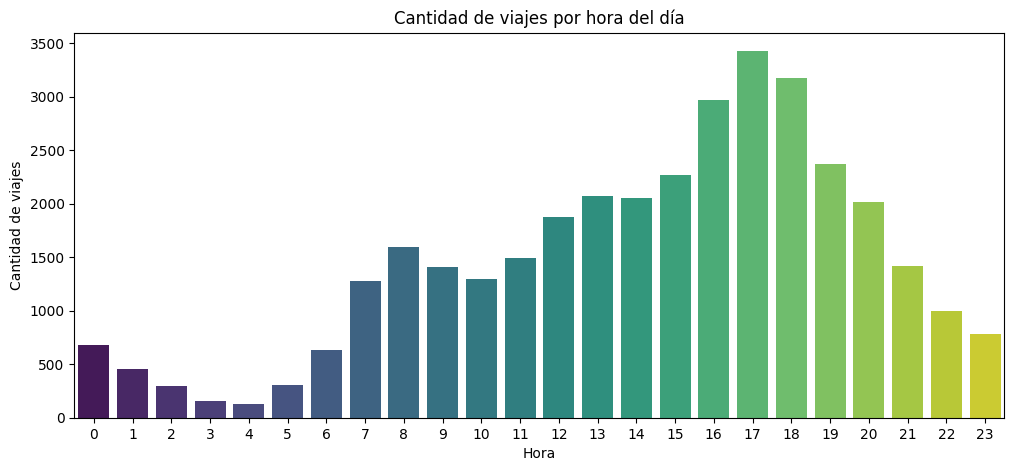

In [18]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='hora_inicio', palette='viridis')
plt.title('Cantidad de viajes por hora del día')
plt.xlabel('Hora')
plt.ylabel('Cantidad de viajes')
plt.show()

### 4\.3\. Distribución de viajes por modelo de bicicleta

/tmp/ipykernel_460/3618592808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='modelo_bicicleta', palette='Set2')


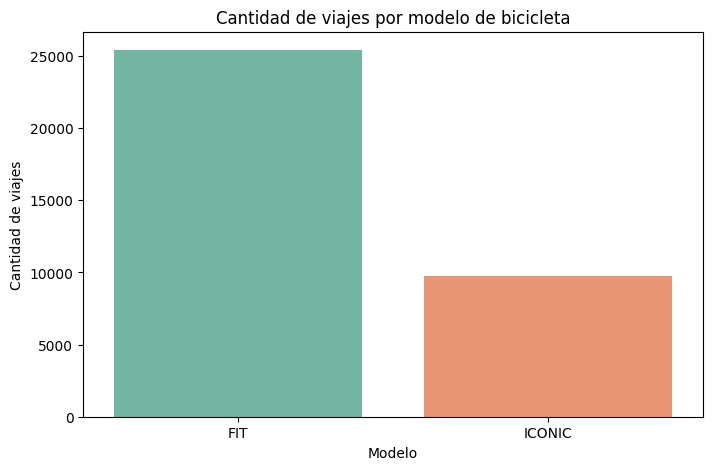

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='modelo_bicicleta', palette='Set2')
plt.title('Cantidad de viajes por modelo de bicicleta')
plt.xlabel('Modelo')
plt.ylabel('Cantidad de viajes')
plt.show()

### 4\.4\. Distribución de viajes por género

/tmp/ipykernel_460/338129586.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='genero', palette='pastel')


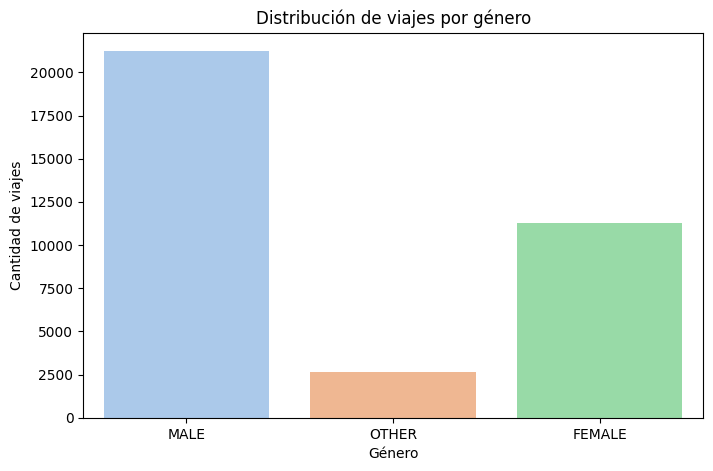

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='genero', palette='pastel')
plt.title('Distribución de viajes por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de viajes')
plt.show()

## 5\. Análisis Bivariado y Multivariado

Exploramos la relación entre dos o más variables\.

### 5\.1\. Duración promedio por género

/tmp/ipykernel_460/478643754.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_filtrado, x='genero', y='duracion_minutos', estimator=np.mean, palette='coolwarm')


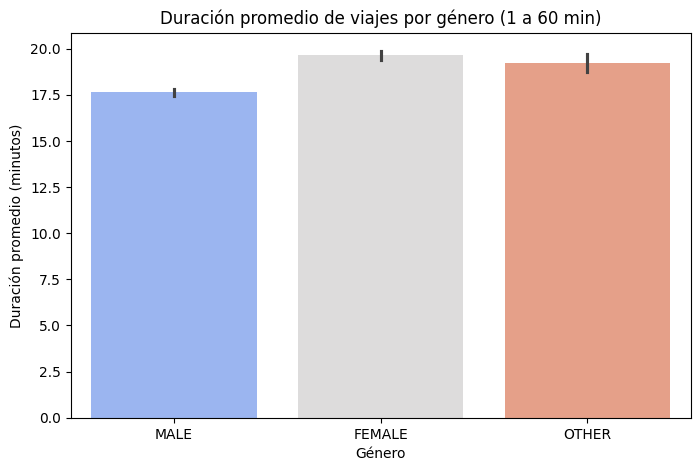

In [21]:
# para este análisis utilizamos el dataset filtrado (1 a 60 min)

plt.figure(figsize=(8,5))
sns.barplot(data=df_filtrado, x='genero', y='duracion_minutos', estimator=np.mean, palette='coolwarm')
plt.title('Duración promedio de viajes por género (1 a 60 min)')
plt.xlabel('Género')
plt.ylabel('Duración promedio (minutos)')
plt.show()

### 5\.2\. Duración promedio por género

/tmp/ipykernel_460/3148934230.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_duracion, x='genero', y='duracion_recorrido', palette='Set2', ax=axes[0])
/tmp/ipykernel_460/3148934230.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_dist, x='genero', y='distancia_recorrida_km', palette='Set3', inner="quartile", ax=axes[1])


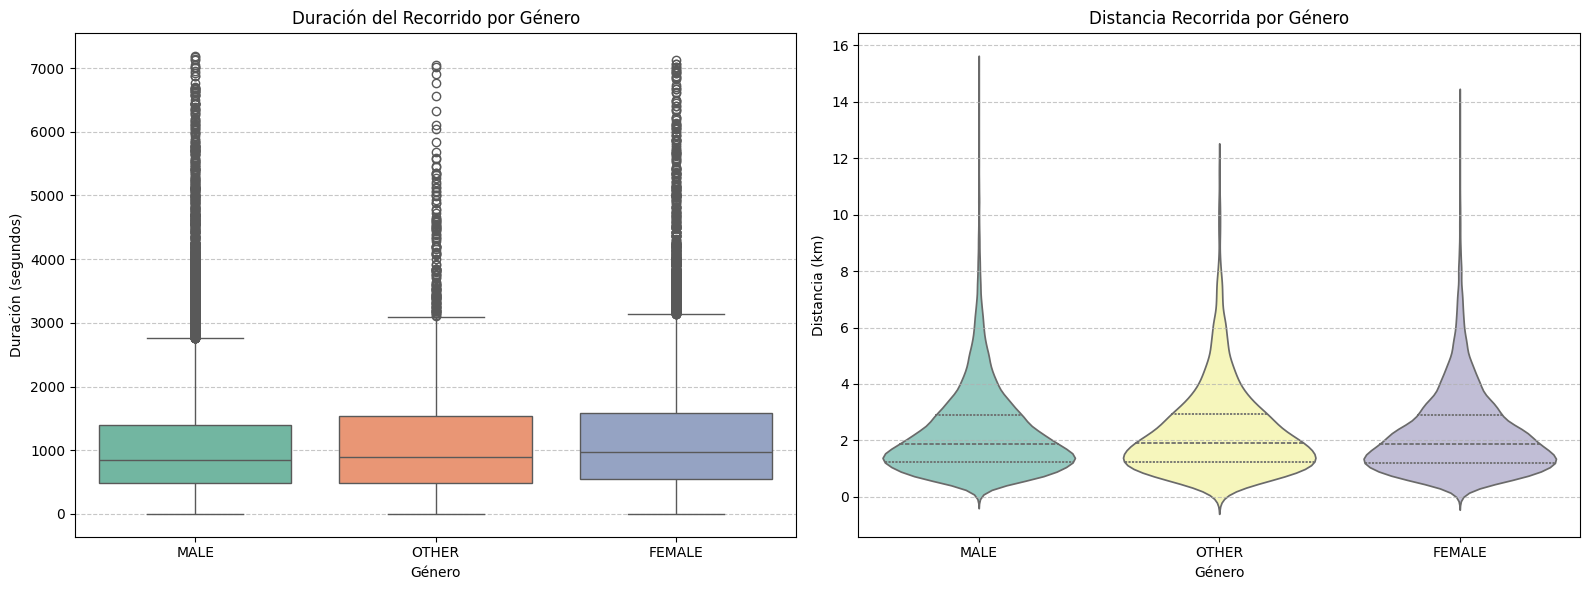

--- Estadísticas de Duración (seg) por Género ---


,count,mean,std,min,25%,50%,75%,max
genero,,,,,,,,
FEMALE,11168.0,1196.69,994.90,2.0,542.00,975.0,1580.00,7128.0
MALE,21104.0,1064.32,905.96,1.0,487.00,844.0,1394.00,7194.0
OTHER,2628.0,1149.62,1028.81,2.0,480.75,889.5,1529.25,7048.0


\n--- Estadísticas de Distancia (km) por Género ---


,count,mean,std,min,25%,50%,75%,max
genero,,,,,,,,
FEMALE,9547.0,2.25,1.48,0.02,1.21,1.88,2.88,13.99
MALE,18665.0,2.26,1.50,0.02,1.23,1.87,2.89,15.22
OTHER,2249.0,2.32,1.57,0.07,1.23,1.92,2.93,11.86


In [22]:
# Configurar la figura con 2 subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de Duración vs Género (Filtramos viajes > 2hs para evitar outliers extremos)
df_duracion = df[df['duracion_recorrido'] <= 7200]
sns.boxplot(data=df_duracion, x='genero', y='duracion_recorrido', palette='Set2', ax=axes[0])
axes[0].set_title('Duración del Recorrido por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Duración (segundos)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Gráfico de Distancia vs Género (Filtramos viajes circulares de 0km y > 20km)
df_dist = df[(df['distancia_recorrida_km'] > 0) & (df['distancia_recorrida_km'] <= 20)]
sns.violinplot(data=df_dist, x='genero', y='distancia_recorrida_km', palette='Set3', inner="quartile", ax=axes[1])
axes[1].set_title('Distancia Recorrida por Género')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Distancia (km)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Mostrar resumen estadístico agrupado
print("--- Estadísticas de Duración (seg) por Género ---")
display(df_duracion.groupby('genero')['duracion_recorrido'].describe().round(2))

print("\\n--- Estadísticas de Distancia (km) por Género ---")
display(df_dist.groupby('genero')['distancia_recorrida_km'].describe().round(2))

### 5\.3\. Duración promedio por hora del día

/tmp/ipykernel_460/2571564508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_prom_hora, x='hora_inicio', y='duracion_minutos', palette='coolwarm')


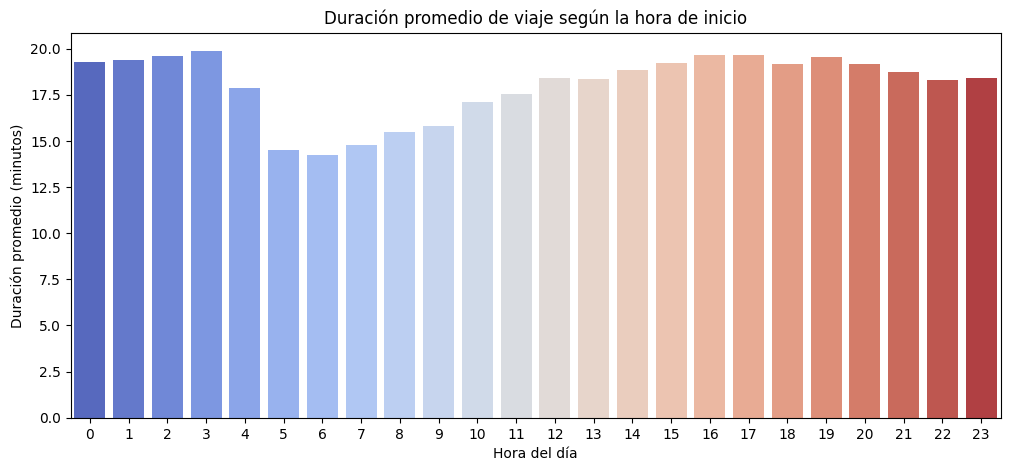

In [23]:
df_prom_hora = df_filtrado.groupby('hora_inicio')['duracion_minutos'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=df_prom_hora, x='hora_inicio', y='duracion_minutos', palette='coolwarm')
plt.title('Duración promedio de viaje según la hora de inicio')
plt.xlabel('Hora del día')
plt.ylabel('Duración promedio (minutos)')
plt.show()


### 5\.4\. Duración promedio por modelo de bicicleta y género

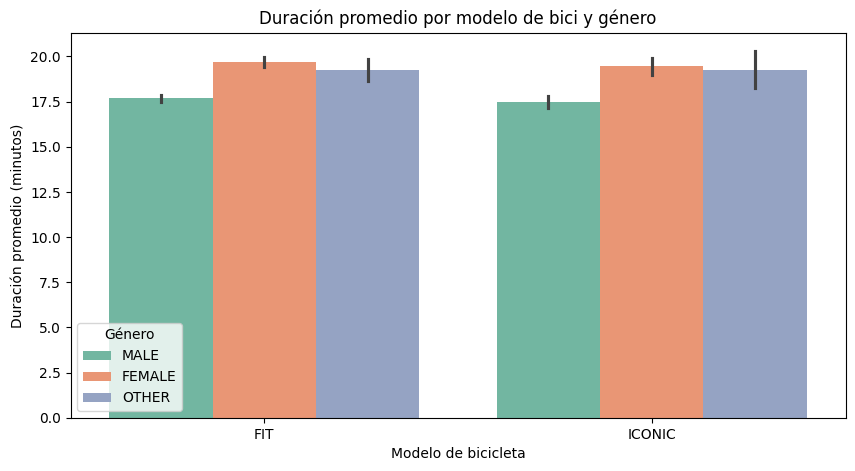

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_filtrado, x='modelo_bicicleta', y='duracion_minutos', hue='genero', estimator=np.mean, palette='Set2')
plt.title('Duración promedio por modelo de bici y género')
plt.xlabel('Modelo de bicicleta')
plt.ylabel('Duración promedio (minutos)')
plt.legend(title='Género')
plt.show()

### 5\.5\. Correlación: hora de inicio vs duración del recorrido

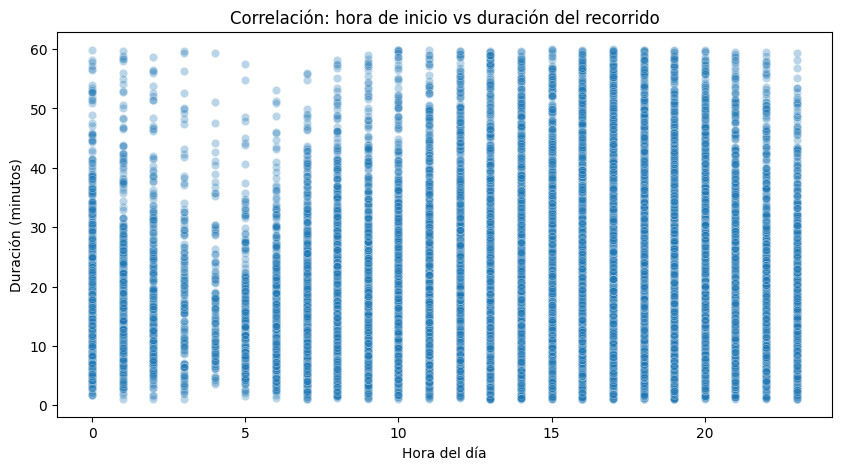

In [25]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_filtrado, x='hora_inicio', y='duracion_minutos', alpha=0.3)
plt.title('Correlación: hora de inicio vs duración del recorrido')
plt.xlabel('Hora del día')
plt.ylabel('Duración (minutos)')
plt.show()


## 6\. Hipótesis y gráficas

Planteamos 4 hipótesis y las verificamos con gráficas\.

### Hipótesis 1: Los viajes son más largos durante el fin de semana que durante la semana laboral

Razonamiento: Durante la semana la gente usa el servicio de ecobici para ir al trabajo, o sea que son viajes cortos y directos\. En cambio, los fines de semana el uso puede ser más recreativo, lo que llevaría a viajes más largos\.

/tmp/ipykernel_460/4197587296.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado, x='tipo_dia', y='duracion_minutos', palette='Set3')


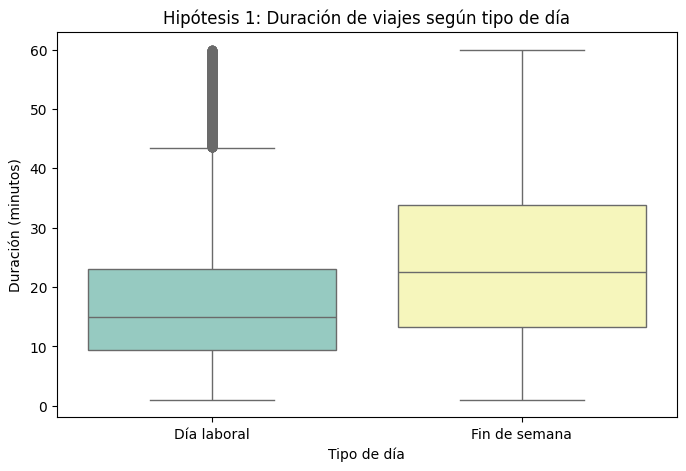

                 count       mean        std       min        25%        50%  \
tipo_dia                                                                       
Día laboral    27284.0  17.461264  10.911540  1.016667   9.333333  14.883333   
Fin de semana   3879.0  24.865305  14.248224  1.016667  13.225000  22.616667   

                     75%        max  
tipo_dia                             
Día laboral    23.000000  59.983333  
Fin de semana  33.891667  59.916667  


In [26]:
# Crear columna de tipo de día
df_filtrado = df_filtrado.copy()
df_filtrado['tipo_dia'] = df_filtrado['dia_semana'].apply(
    lambda x: 'Fin de semana' if x in ['Saturday', 'Sunday'] else 'Día laboral'
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_filtrado, x='tipo_dia', y='duracion_minutos', palette='Set3')
plt.title('Hipótesis 1: Duración de viajes según tipo de día')
plt.xlabel('Tipo de día')
plt.ylabel('Duración (minutos)')
plt.show()

# Estadísticas
print(df_filtrado.groupby('tipo_dia')['duracion_minutos'].describe())


Se confirma la hipótesis\. Los datos muestran que existe una diferencia significativa en la duración de los viajes según el tipo de día\. En promedio, los usuarios usan las bicicletas durante 7 minutos más los fines de semana que en los días laborales \(lunes a viernes\), lo que valida la idea que se utiliza de manera más recreativa hacia el fin de semana \(sábados y domingos\)\.

### Hipótesis 2: No hay diferencia significativa en la duración promedio de viaje entre géneros

Razonamiento: El sistema de bicis compartidas se usa para viajes cortos, independientemente del género del usuario\. La duración promedio no debería variar drásticamente según el género\.

/tmp/ipykernel_460/2477938754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_filtrado, x='genero', y='duracion_minutos', palette='muted')


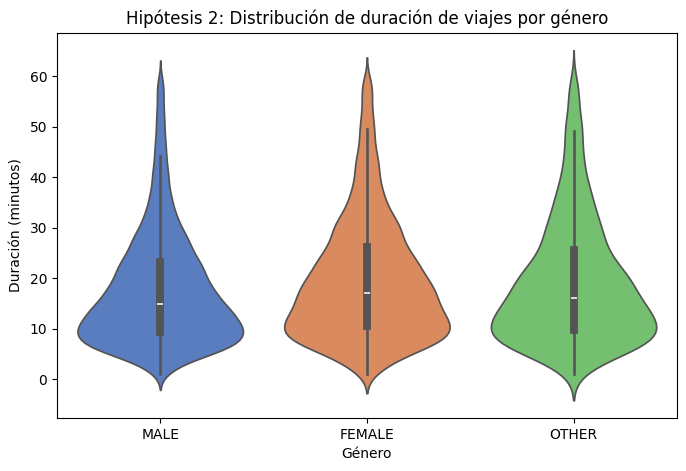

          count       mean        std       min        25%        50%  \
genero                                                                  
FEMALE   9899.0  19.636078  12.024716  1.016667  10.483333  17.066667   
MALE    19014.0  17.629486  11.279508  1.016667   9.283333  14.791667   
OTHER    2250.0  19.236030  12.361807  1.100000   9.787500  16.066667   

              75%        max  
genero                        
FEMALE  26.083333  59.916667  
MALE    23.266667  59.983333  
OTHER   25.529167  59.866667  


In [27]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_filtrado, x='genero', y='duracion_minutos', palette='muted')
plt.title('Hipótesis 2: Distribución de duración de viajes por género')
plt.xlabel('Género')
plt.ylabel('Duración (minutos)')
plt.show()

# Estadísticas por género
print(df_filtrado.groupby('genero')['duracion_minutos'].describe())


A raíz del gráfico se observa que las distribuciones de tiempo son casi idénticas para los tres géneros del análisis\. Las medianas y promedios se mantienen en un rango estrecho \(17\-19min\), lo que sugiere que el uso del servicio de ecobici es homogéneo y que la duración de los viajes depende más de la ubicación de las estaciones que del género del usuario\.

### Hipótesis 3: La velocidad promedio de los viajes es más alta en los días de semana

In [28]:
tabla_velocidades = df_vel.groupby('tipo_dia').agg(
    viajes=('id_recorrido', 'count'),
    velocidad_media_kmh=('velocidad_km_h', 'mean'),
    velocidad_mediana_kmh=('velocidad_km_h', 'median'),
    velocidad_min_kmh=('velocidad_km_h', 'min'),
    velocidad_p25_kmh=('velocidad_km_h', lambda x: x.quantile(0.25)),
    velocidad_p75_kmh=('velocidad_km_h', lambda x: x.quantile(0.75)),
    velocidad_max_kmh=('velocidad_km_h', 'max'),
    desvio_estandar_kmh=('velocidad_km_h', 'std')
).reset_index()

tabla_velocidades.round(2)

,tipo_dia,viajes,velocidad_media_kmh,velocidad_mediana_kmh,velocidad_min_kmh,velocidad_p25_kmh,velocidad_p75_kmh,velocidad_max_kmh,desvio_estandar_kmh
0,Día hábil,26124,8.07,8.25,0.01,6.35,9.99,19.08,2.94
1,Fin de semana,3791,6.58,6.57,0.05,4.13,8.94,18.22,3.34


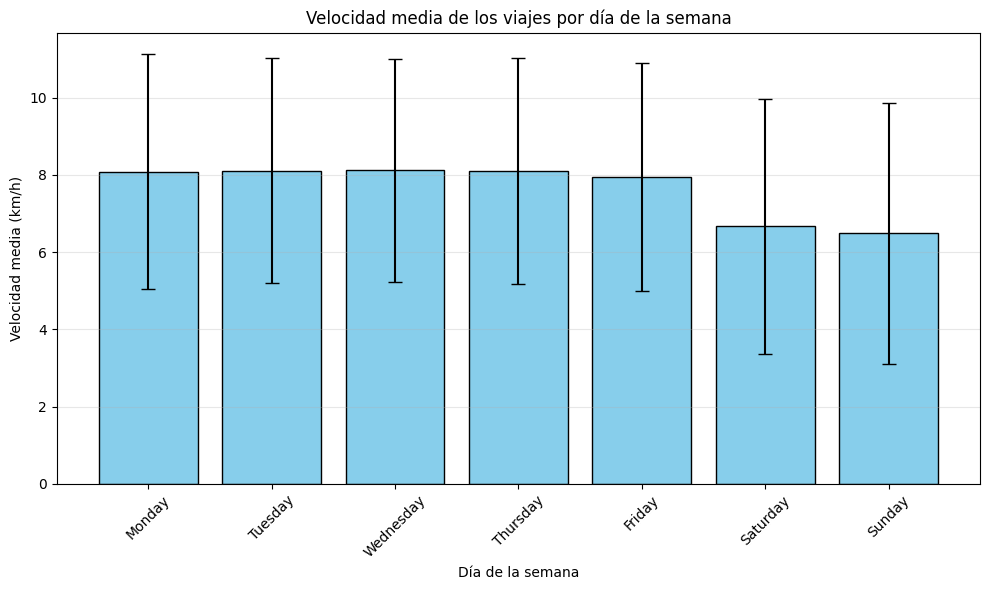

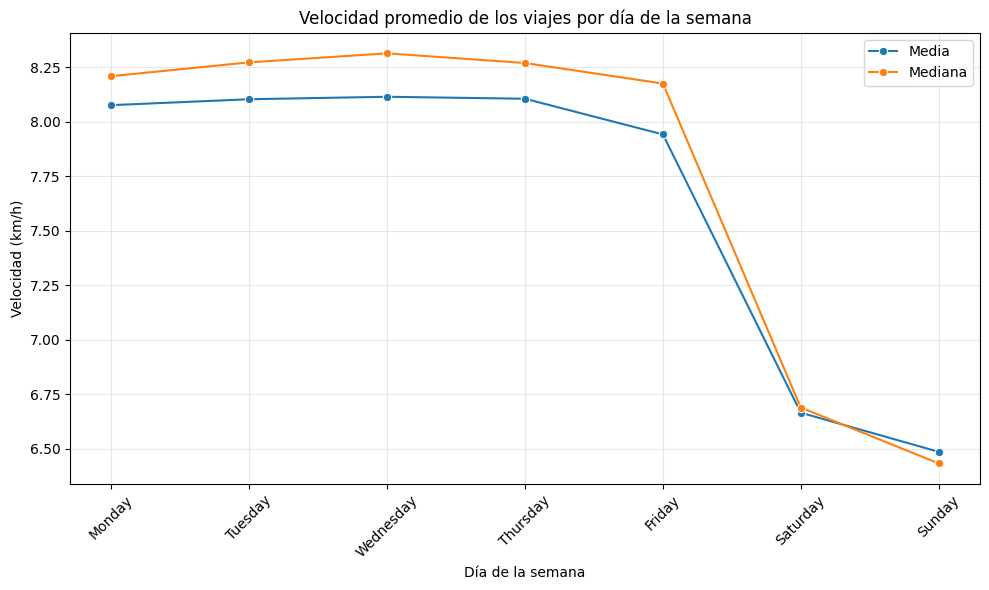

In [29]:
import calendar


# Orden correcto de los días
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

velocidad_por_dia = df_vel.groupby('dia_semana')['velocidad_km_h'].agg(
    media='mean',
    desvio='std',
    conteo='count'
).reindex(orden_dias).reset_index()

plt.figure(figsize=(10,6))
plt.bar(
    velocidad_por_dia['dia_semana'],
    velocidad_por_dia['media'],
    yerr=velocidad_por_dia['desvio'],
    capsize=5,
    color='skyblue',
    edgecolor='black'
)

plt.title('Velocidad media de los viajes por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Velocidad media (km/h)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Resumen de velocidad por día
velocidad_por_dia = df_vel.groupby('dia_semana')['velocidad_km_h'].agg(['mean', 'median', 'count']).reindex(orden_dias).reset_index()

# Graficar
plt.figure(figsize=(10,6))
sns.lineplot(data=velocidad_por_dia, x='dia_semana', y='mean', marker='o', label='Media')
sns.lineplot(data=velocidad_por_dia, x='dia_semana', y='median', marker='o', label='Mediana')

plt.title('Velocidad promedio de los viajes por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Velocidad (km/h)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

La velocidad promedio de los viajes es mayor durante los días de semana que en el fin de semana\. Mientras de lunes a viernes la media se mantiene estable en torno a los 8 km/h, el sábado y el domingo se observa una disminución clara de esta variable, cerca de los 6\.5 km/h\. Muy posiblemente esto se deba a que en los días hábiles la gente prioriza la velocidad para llegar a sus lugares de trabajo\.

### Hipótesis 4: Los viajes realizados en horarios pico de días hábiles son más cortos y más rápidos que los viajes realizados fuera de horario pico\.

In [30]:
tabla_pico = df_vel.groupby(['tipo_dia', 'periodo_horario']).agg(
    viajes=('id_recorrido', 'count'),
    duracion_media_min=('duracion_minutos', 'mean'),
    distancia_media_km=('distancia_recorrida_km', 'mean'),
    velocidad_media_kmh=('velocidad_km_h', 'mean')
).reset_index()

tabla_pico.round(2)

,tipo_dia,periodo_horario,viajes,duracion_media_min,distancia_media_km,velocidad_media_kmh
0,Día hábil,Fuera de pico,15861,20.96,2.18,7.97
1,Día hábil,Hora pico,10263,19.28,2.25,8.23
2,Fin de semana,Fuera de pico,2648,31.20,2.63,6.61
3,Fin de semana,Hora pico,1143,30.56,2.62,6.49


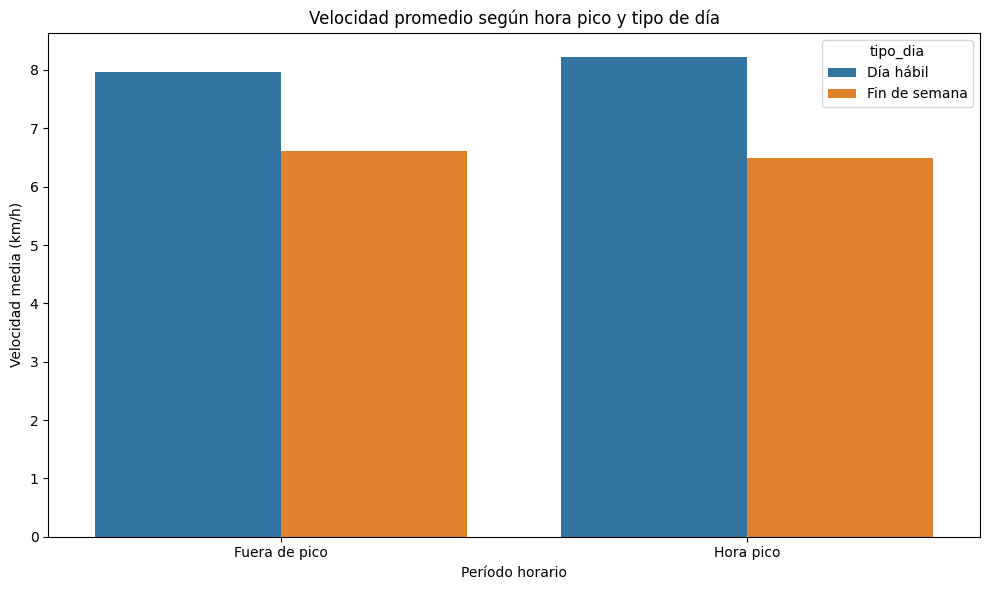

In [31]:
# Velocidad promedio según hora pico y tipo de día
plt.figure(figsize=(10,6))
sns.barplot(data=df_vel, x='periodo_horario', y='velocidad_km_h', hue='tipo_dia', estimator=np.mean, errorbar=None)
plt.title('Velocidad promedio según hora pico y tipo de día')
plt.xlabel('Período horario')
plt.ylabel('Velocidad media (km/h)')
plt.tight_layout()
plt.show()

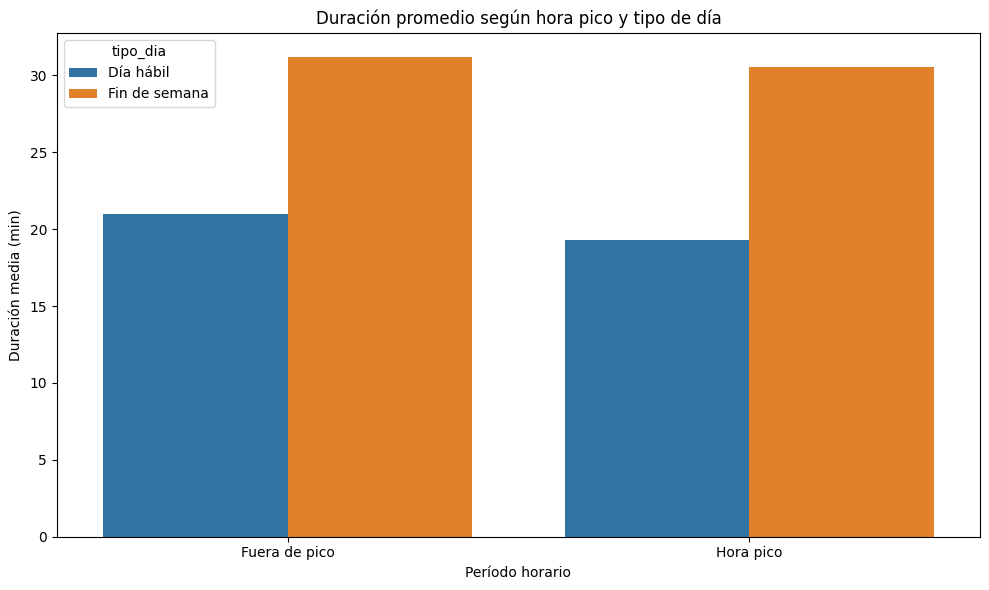

In [32]:
# Duración promedio según hora pico y tipo de día
plt.figure(figsize=(10,6))
sns.barplot(data=df_vel, x='periodo_horario', y='duracion_minutos', hue='tipo_dia', estimator=np.mean, errorbar=None)
plt.title('Duración promedio según hora pico y tipo de día')
plt.xlabel('Período horario')
plt.ylabel('Duración media (min)')
plt.tight_layout()
plt.show()

Los gráficos muestran que los viajes de los días hábiles presentan mayor velocidad promedio y menor duración que  durante el fin de semana\. Además, dentro de los días hábiles, los viajes en hora pico tienden a ser levemente más veloces y más cortos que fuera de pico\. 

## 7\. Modelado de Machine Learning: Predicción de Tipo de Día \(Laboral vs\. Fin de Semana\)

En esta sección final, aplicaremos modelos de aprendizaje automático para resolver un problema de Clasificación Binaria: predecir si un viaje en Ecobici se realizó en un Fin de Semana \(1\) o en un Día Hábil \(0\)\.

### Justificación del objetivo y variables:


Target: target = es\_fin\_de\_semana \( 1 si es fin de semana, 0 si es día laboral\)\. Esta variable está ligada con el uso recreativo frente al utilitario, un patrón clave observado en el análisis descriptivo y de hipótesis\.
Features: Usaremos características operativas del viaje: hora\_inicio, duracion\_minutos, distancia\_recorrida\_km, velocidad\_km\_h, viaje\_circular \(si empieza y termina en la misma estación\), genero y modelo\_bicicleta\.
Modelos: Evaluaremos y compararemos tres algoritmos clásicos de clasificación:

1\) Regresión Logística: Modelo de clasificación lineal para establecer una base de referencia\.

2\) Árbol de Decisión: Modelo no lineal intuitivo, fácil de interpretar y de explicar de forma didáctica\.

3\) Random Forest: Ensamble de múltiples árboles de decisión para capturar patrones más complejos y reducir variabilidad\.

Para resolver el fuerte desbalance de clases \(los fines de semana concentran solo el 11\.8% de los viajes\), utilizaremos el hiperparámetro class\_weight='balanced' en todos los clasificadores\. Esto penaliza más los errores en la clase minoritaria y mejora sustancialmente la sensibilidad \(Recall\)\.


### Preparación y partición

Preparación de los datos y división Train/Test

In [33]:
# Importaciones necesarias para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Preparación del dataset consolidando la limpieza y filtros de df_vel
df_model = df[
    (df['velocidad_km_h'] > 0) &
    (df['velocidad_km_h'] <= 30) &
    (df['duracion_minutos'] > 1) &
    (df['duracion_minutos'] < 60) &
    (df['distancia_recorrida_km'] > 0)
].copy()

# Definición de variable objetivo (Target) y predictoras (Features)
df_model['target'] = df_model['es_fin_de_semana'].astype(int)

X = df_model[['hora_inicio', 'duracion_minutos', 'distancia_recorrida_km', 'velocidad_km_h', 'viaje_circular', 'genero', 'modelo_bicicleta']]
y = df_model['target']

# Partición en entrenamiento (80%) y prueba (20%) estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Filas de entrenamiento: {len(X_train)}")
print(f"Filas de prueba: {len(X_test)}")
print(f"\nDistribución de clases en entrenamiento (0: Día hábil, 1: Fin de semana):\n{y_train.value_counts(normalize=True)}")

Filas de entrenamiento: 23199
Filas de prueba: 5800

Distribución de clases en entrenamiento (0: Día hábil, 1: Fin de semana):
target
0    0.881504
1    0.118496
Name: proportion, dtype: float64


### Preprocesamiento y entrenamiento \(métricas\)

Preprocesamiento y entrenamiento de modelos

In [34]:
# Definición del Pipeline de preprocesamiento
numeric_features = ['hora_inicio', 'duracion_minutos', 'distancia_recorrida_km', 'velocidad_km_h']
categorical_features = ['genero', 'modelo_bicicleta', 'viaje_circular']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Definición de los 3 modelos con balanceo de pesos de clase
models = {
    'Regresión Logística (Balanced)': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Árbol de Decisión (Balanced)': DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'),
    'Random Forest (Balanced)': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight="balanced",)
}

results = {}
metrics_list = []

for name, clf in models.items():
    # Crear pipeline unificado
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', clf)])
    
    # Entrenamiento
    pipeline.fit(X_train, y_train)
    
    # Predicciones
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        'pipeline': pipeline,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'cm': cm
    }
    
    metrics_list.append({
        'Modelo': name,
        'Exactitud (Accuracy)': acc,
        'Precisión (Precision)': prec,
        'Sensibilidad (Recall)': rec,
        'F1-Score': f1
    })

# Mostrar DataFrame comparativo de métricas
df_metrics = pd.DataFrame(metrics_list)
display(df_metrics.round(4))

,Modelo,Exactitud (Accuracy),Precisión (Precision),Sensibilidad (Recall),F1-Score
0,Regresión Logística (Balanced),0.7017,0.2082,0.5415,0.3007
1,Árbol de Decisión (Balanced),0.7140,0.2178,0.5459,0.3113
2,Random Forest (Balanced),0.7072,0.2181,0.5691,0.3153


### Matrices de confusión

Evaluación detallada: Matrices de confusión

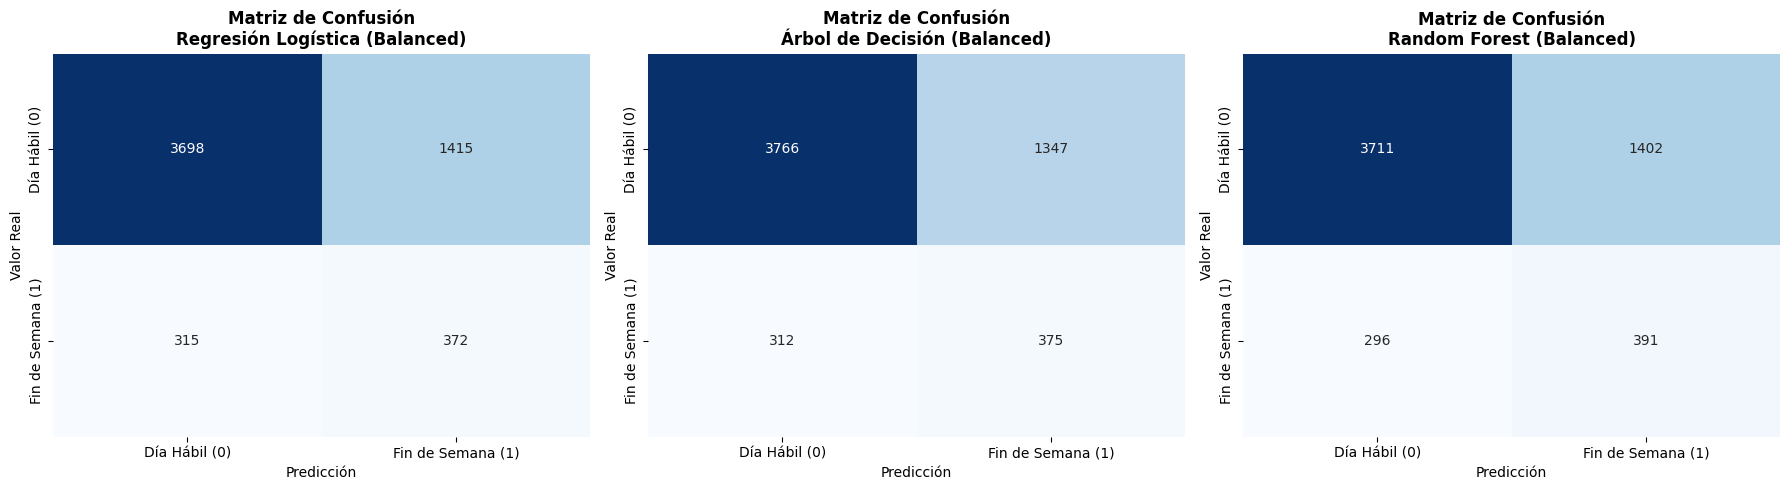

In [35]:
# Graficado de las Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, res) in enumerate(results.items()):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Día Hábil (0)', 'Fin de Semana (1)'],
                yticklabels=['Día Hábil (0)', 'Fin de Semana (1)'])
    axes[idx].set_title(f"Matriz de Confusión\n{name}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Predicción")
    axes[idx].set_ylabel("Valor Real")
    
plt.tight_layout()
plt.show()

### Curvas ROC \(receiver operating characteristic\) y AUC \(área bajo la curva\)

Comparación de capacidad predictiva: Curvas ROC \(capacidad de detectar casos reales, o sea la sensibilidad, sin llenarse de falsos positivos\)

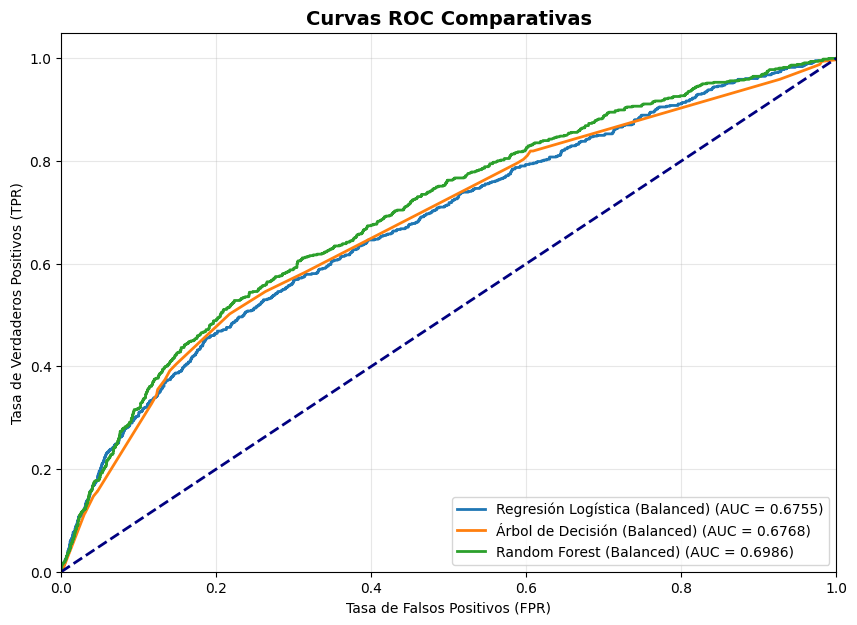

In [36]:
# Graficado comparativo de Curvas ROC
plt.figure(figsize=(10, 7))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})", lw=2)

plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Comparativas', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## 8\. Análisis crítico, didáctico e interpretación de resultados\.

En esta sección analizamos los resultados obtenidos de acuerdo con la teoría de la matriz de confusión y las métricas de evaluación:

### A\. Explicación de las métricas en este contexto:

1\. Exactitud \(accuracy\): Representa la proporción de predicciones correctas realizadas por el modelo\. En nuestro caso, ronda el 70\-71% para todos los modelos\. Aunque en un principio pueda parecer más baja que el 88% del modelo sin balancear, esta exactitud es real y útil\. En el modelo inicial sin balanceo, se obtenía un 88% artificial simplemente prediciendo que todos los viajes eran de días hábiles\. Al balancear las clases, logramos un modelo que realmente puede distinguir ambos tipos de días\.

2\. Precisión \(precision\): Indica de todos los viajes que el modelo predijo como "Fin de Semana", cuántos realmente lo eran\. Se sitúa en torno al 21%\. Esto nos dice que el modelo genera bastantes Falsos Positivos \(viajes en días de semana que clasifica como fin de semana\)\. Esto es biológicamente y socialmente lógico: muchas personas realizan recorridos pausados, cortos o circulares durante la semana laboral que imitan perfectamente la conducta de fin de semana\.

3\. Sensibilidad \(Recall\): Mide la proporción de viajes de "Fin de Semana" reales que el modelo fue capaz de detectar\. Es nuestra métrica clave en este problema\. Pasó de 0% a más del 54\-57%\. Esto significa que los modelos ahora logran identificar correctamente a la mayoría de los ciclistas recreativos\.

4\. F1\-Score: Es el promedio armónico entre la Precisión y el Recall\. Da una visión equilibrada del desempeño general del modelo en la clase minoritaria, estabilizándose en torno a 0\.31\.

### B\. Análisis de las Matrices de Confusión:

Analizando la matriz del modelo Random Forest \(Balanced\):

Analizando la matriz del modelo Random Forest \(ya que es el modelo "ganador" debido a sus métricas generales\):

 Verdaderos Negativos \(Día Hábil predicho como Día Hábil\): ~3,689 viajes\. El modelo clasifica correctamente la gran mayoría de los viajes cotidianos de transporte laboral\.

• Falsos Positivos \(Día Hábil predicho como Fin de Semana\): ~1,424 viajes\. Representan viajes de días laborales que muestran patrones relajados  recreativos \(duraciones más largas, velocidad más baja o viajes circulares\)\.

• Falsos Negativos \(Fin de Semana predicho como Día Hábil\): ~292 viajes\. Viajes recreativos que son rápidos y lineales, imitando los viajes cotidianos\.

• Verdaderos Positivos \(Fin de Semana predicho como Fin de Semana\): ~395 viajes\. Representan los viajes reales de fin de semana que el modelo logra detectar exitosamente\.

### C\. Selección del Modelo Más Indicado \(la decisión final\):

•El modelo seleccionado es el Random Forest Classifier \(Balanced\)\.

•Justificación:

1\. Presenta la mayor Sensibilidad \(Recall: ~57\.50%\), lo cual es de vital importancia si el objetivo operativo es poder "pescar" e identificar la mayor proporción de usuarios de fin de semana para campañas específicas\.

2\. Obtiene el F1\-Score más alto \(~0\.315\), que indica la mejor relación de compromiso general entre precisión y sensibilidad en condiciones de desbalance\.

3\. Tiene el mayor valor de Área Bajo la Curva ROC \(AUC\) en la comparación visual, demostrando matemáticamente que es el clasificador con mejor capacidad discriminativa global\.

### D\. Análisis de valores mas influyentes

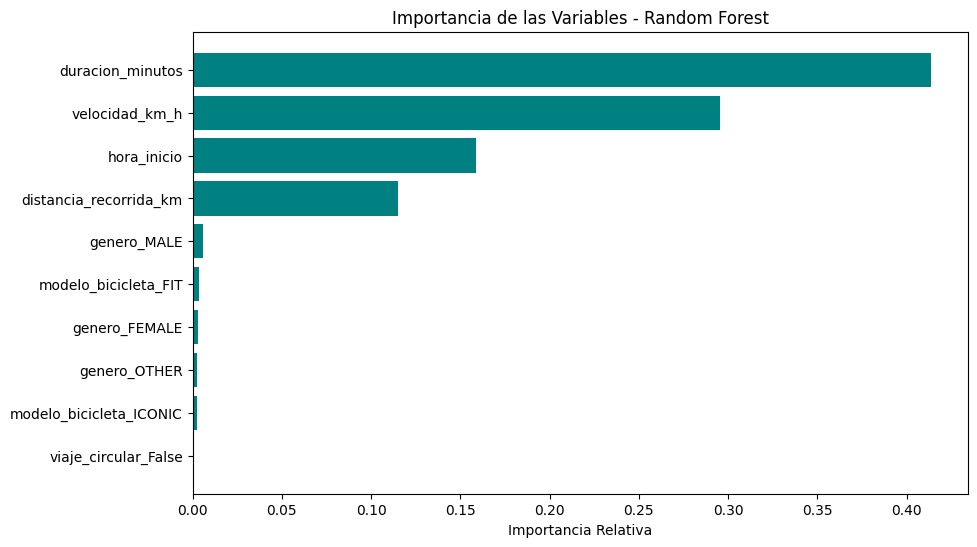

In [37]:
from sklearn.model_selection import cross_val_score

# 1. Importancia de las variables (Feature Importance)
# Accedemos al clasificador dentro del pipeline del modelo ganador
rf_pipeline = results['Random Forest (Balanced)']['pipeline']
rf_classifier = rf_pipeline.named_steps['classifier']

# Obtener nombres de columnas tras el preprocesamiento
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(encoded_cat_names)

importances = rf_classifier.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importancia de las Variables - Random Forest')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.show()

# 2. Validación Cruzada para asegurar estabilidad
# Usamos F1-score como métrica por el desbalance de clases
scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='f1')


Aquí confirmamos que los factores mas influyentes para determinar si el viaje corresponde a uno realizado en un día hábil o fin de semana son aquellos valores cuantitativos relacionados al viaje realizado por el usuario sin influir valores categóricos como modelo de bicicleta o género\. 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=429deba9-dfa0-4717-ba29-e2e1e1697ecc' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>